In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy import special
from tqdm import tqdm
from math import floor
import statsmodels.api as sm

In [2]:
def gen():
    return int(np.random.random() * 10**6)

# 1. Генерация данных

In [3]:
def generator_uniform(n):
    return np.random.uniform(-np.sqrt(3), np.sqrt(3), n)

def generator_normal(n):
    return np.random.normal(0, 1, n)

def generator_exponential(n):
    return stats.expon(scale=1, loc=-1).rvs(size=n, random_state=gen())

In [4]:
samples_count = 10**3
n_values = [10, 50, 100, 150, 200, 500]

samples = {
    'uniform' : [generator_uniform(n) for n in n_values],
    'normal' : [generator_normal(n) for n in n_values],
    'exponential' : [generator_exponential(n) for n in n_values],
}

# 2. Проверка гипотез:

$$H_0 : |\mathbb{E}\xi| < a$$

$$H_1 : |\mathbb{E}\xi| > a$$

$$a = 5$$

In [5]:
a = 5
alpha, beta = 0.05, 0.05

In [6]:
def get_interval_for_mean(sample, Q=0.95):
    m = np.mean(sample)
    D = np.var(sample)
    n = sample.size

    return (
        m + special.stdtrit(n - 1, (1 - Q) / 2) * np.sqrt(D / n),
        m + special.stdtrit(n - 1, (1 + Q) / 2) * np.sqrt(D / n)
    )

In [7]:
def check_hypothesis(sample, a, alpha=0.05, beta=0.05):
    l_alpha, r_alpha = get_interval_for_mean(sample, Q=1-alpha)
    l_beta, r_beta  = get_interval_for_mean(sample, Q=1-beta)

    if -a <= l_beta <= r_beta <= a:
        return 0
    elif r_alpha <= -a or a <= l_alpha:
        return 1
    else:
        return 1

In [8]:
def calc_I_error(generator, sample_size, a, experiments_count=10**3):
    I_error_count = 0
    for _ in range(experiments_count):
        sample = generator(sample_size)
        I_error_count += check_hypothesis(sample, a)
    return I_error_count / experiments_count

In [9]:
I_errors = {
    'uniform' : [calc_I_error(generator_uniform, n, 0.5) for n in tqdm(n_values)],
    'normal' : [calc_I_error(generator_normal, n, 0.5) for n in tqdm(n_values)],
    'exponential' : [calc_I_error(generator_exponential, n, 0.5) for n in tqdm(n_values)],
}

100%|██████████| 6/6 [00:08<00:00,  1.46s/it]


In [10]:
I_errors

{'uniform': [0.991, 0.121, 0.0, 0.0, 0.0, 0.0],
 'normal': [0.971, 0.145, 0.004, 0.0, 0.0, 0.0],
 'exponential': [0.948, 0.134, 0.012, 0.0, 0.0, 0.0]}

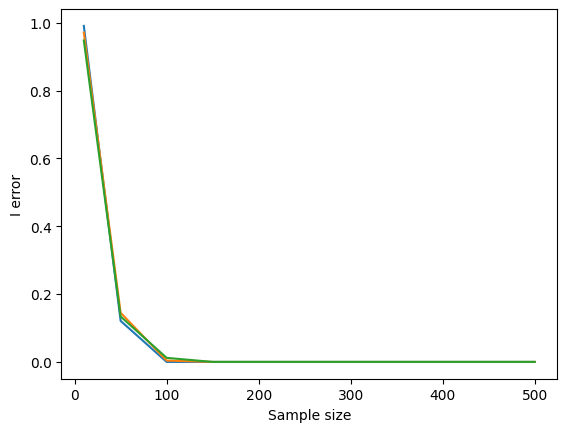

<Figure size 640x480 with 0 Axes>

In [11]:
data_1 = pd.DataFrame({
    'I error' : I_errors['uniform'],
    'Sample size' : n_values
})

data_2 = pd.DataFrame({
    'I error' : I_errors['normal'],
    'Sample size' : n_values
})

data_3 = pd.DataFrame({
    'I error' : I_errors['exponential'],
    'Sample size' : n_values
})

sns.lineplot(data=data_1, y='I error', x='Sample size')
sns.lineplot(data=data_2, y='I error', x='Sample size')
sns.lineplot(data=data_3, y='I error', x='Sample size')

plt.show()
plt.tight_layout()

# 3. Двигаем истинное матожидание

In [12]:
biases = np.arange(0.2, 2*a + 0.2, 0.2).tolist()

In [13]:
def get_generator_uniform_biased(bias):
    def generator_uniform_biased(n):
        return np.sort(np.random.uniform(-np.sqrt(3), np.sqrt(3), n)) + bias
    return generator_uniform_biased

def get_generator_normal_biased(bias):
    def generator_normal_biased(n):
        return np.sort(np.random.normal(bias, 1, n))
    return generator_normal_biased

def get_generator_exponential_biased(bias):
    def generator_exponential_biased(n):
        return np.sort(stats.expon(scale=1, loc=-1 + bias).rvs(size=n, random_state=gen()))
    return generator_exponential_biased

In [14]:
def calc_I_error_biased(generator, bias, sample_size, a, experiments_count=10**3):
    I_error_count = 0
    for _ in range(experiments_count):
        sample = generator(sample_size)
        I_error_count += 1 if check_hypothesis(sample, a) == 1 and bias <= 5 else 0
    return I_error_count / experiments_count

In [15]:
I_errors = {'n=10' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
},
'n=50' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
},
'n=100' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
},
'n=200' : {
    'uniform' : [calc_I_error_biased(get_generator_uniform_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'normal' : [calc_I_error_biased(get_generator_normal_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
    'exponential' : [calc_I_error_biased(get_generator_exponential_biased(bias), bias, 10, 0.5) for bias in tqdm(biases)],
}
}

100%|██████████| 50/50 [01:06<00:00,  1.34s/it]


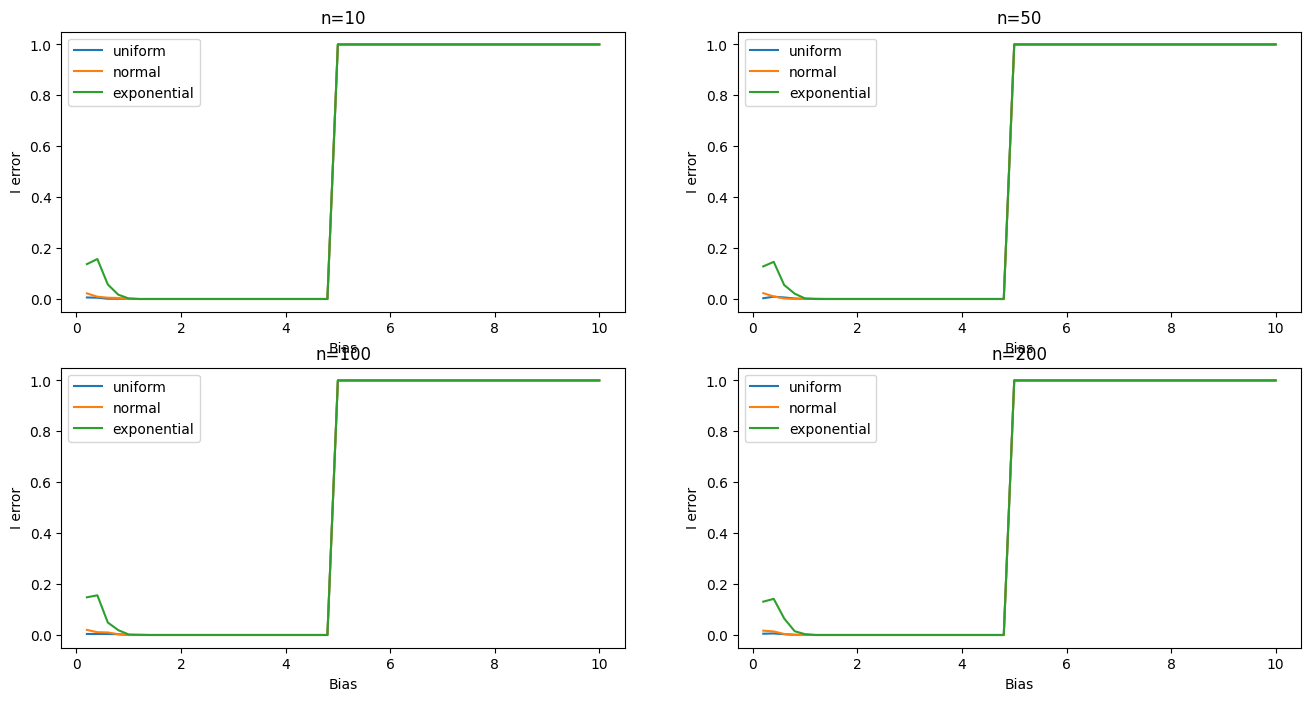

<Figure size 640x480 with 0 Axes>

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

for i in range(2):
    for j in range(2):
        name = list(I_errors.keys())[2*i + j]
        I_errors_subset = I_errors[name]
        data_1 = pd.DataFrame({
            'I error' : [1 - item for item in I_errors_subset['uniform']],
            'Bias' : biases
        })
        data_2 = pd.DataFrame({
            'I error' : [1 - item for item in I_errors_subset['normal']],
            'Bias' : biases
        })
        data_3 = pd.DataFrame({
            'I error' : [1 - item for item in I_errors_subset['exponential']],
            'Bias' : biases
        })

        sns.lineplot(data=data_1, y='I error', x='Bias', ax=axes[i][j], label='uniform')
        sns.lineplot(data=data_2, y='I error', x='Bias', ax=axes[i][j], label='normal')
        sns.lineplot(data=data_3, y='I error', x='Bias', ax=axes[i][j], label='exponential')

        axes[i][j].set_title(name)
        axes[i][j].set_ylim(-0.05, 1.05)

plt.show()
plt.tight_layout()